# Query analysis

Gold source rank per query, for every `(collection, alpha)` cell. One row per
query; six rank columns (two collections × three alphas). Low rank = found near
the top; `51` (= `top_k + 1`) = gold never retrieved within `top_k`.

In [10]:
from minerva_eval import load_all_results, gold_ranks, paired_chunk_deltas, paired_chunk_winloss
import pandas as pd

all_results = load_all_results()
print(f"{len(all_results)} results, {len({r.query_id for r in all_results})} queries")

330 results, 55 queries


## Gold rank across cells

For one query, the gold article's best chunk rank in every `(collection, alpha)`
cell. `rank <= 10` == recall@10 hit; `rank == top_k+1` (51) == gold beyond `top_k`
(a coverage miss, not a ranking miss). Compare `nollm` vs `qwen2-5` at matched
alpha to test whether contextualization improves ranking.

In [ ]:
def gold_chunk_ranks(query_id: str) -> pd.DataFrame:
    """Gold source rank per (collection, alpha) cell, for one query.
    rank <= 10 == recall@10 hit; rank == top_k+1 == gold beyond top_k (coverage miss)."""
    ranks = pd.DataFrame(vars(g) for g in gold_ranks(all_results))
    ranks = ranks[ranks["query_id"] == query_id]
    return ranks.pivot_table(index=["gold", "collection"], columns="alpha",
                             values="rank", aggfunc="first")

gold_chunk_ranks("The_Beatles.md-2")

alpha                             0.3  0.5  0.7
gold           collection                      
The_Beatles.md wikipedia-nollm     18   18    9
               wikipedia-qwen2-5   18    7    4

## Gold rank per query — collection comparison

The whole-sample version of the cell above. At a fixed alpha, plot each query's
gold rank under `nollm` (x) against `qwen2-5` (y). Points **below** the diagonal
are queries where contextualization ranks the gold better; distance from the line
is the magnitude; cluster tightness is the consistency. The printed counts and
median rank delta summarize what the MRR@10 mean in the metrics view hides: the
pairing, the spread, and any regressions.

Missing gold (beyond `top_k`) maps to `top_k + 1`, so coverage misses plot at the
edge rather than dropping out.

alpha=0.5  wikipedia-qwen2-5 vs wikipedia-nollm:  better: 11  worse: 7  tied: 37  median delta: 0.0


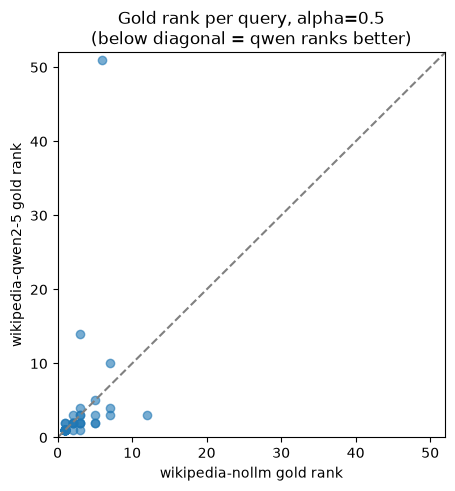

In [ ]:
import matplotlib.pyplot as plt

def gold_rank_per_query(alpha: float) -> pd.DataFrame:
    """Worst gold rank per query, one column per collection, at a fixed alpha.
    Missing gold (beyond top_k) is already mapped to top_k+1 by gold_ranks, so it plots as 'worst'."""
    ranks = pd.DataFrame(vars(g) for g in gold_ranks(all_results))
    ranks = ranks[ranks["alpha"] == alpha]
    return ranks.pivot_table(index="query_id", columns="collection",
                             values="rank", aggfunc="max")

ALPHA = 0.5
A, B = "wikipedia-nollm", "wikipedia-qwen2-5"

cmp = gold_rank_per_query(ALPHA)
delta = cmp[B] - cmp[A]
print(f"alpha={ALPHA}  {B} vs {A}:  "
      f"better: {(delta < 0).sum()}  worse: {(delta > 0).sum()}  "
      f"tied: {(delta == 0).sum()}  median delta: {delta.median()}")

lim = 52
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(cmp[A], cmp[B], alpha=0.6)
ax.plot([0, lim], [0, lim], "--", color="gray")
ax.set_xlabel(f"{A} gold rank")
ax.set_ylabel(f"{B} gold rank")
ax.set_title(f"Gold rank per query, alpha={ALPHA}\n(below diagonal = qwen ranks better)")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
plt.show()

## Paired chunk comparison — does contextualization help?

For each `(query, gold, alpha)`, pair the gold source's chunks between the two
collections on `chunk_index` (recovered by inverting the deterministic
`chunk_id` hash, since `chunk_id = sha256("{collection}:{source_id}:{index}")`
carries no content). Two metrics side by side per alpha:

- **avg**: mean signed rank change `baseline_rank − treatment_rank`. Positive =
  the treatment ranks the gold's chunks higher on average.
- **winloss**: `treatment_wins − baseline_wins`, i.e. how many chunks the
  treatment ranks better minus how many the baseline ranks better (ties ignored).

Each metric is colored on its own symmetric scale (their magnitudes differ).
Green = contextualization helps, red = it hurts.

In [12]:
BASELINE, TREATMENT = "wikipedia-nollm", "wikipedia-qwen2-5"

deltas = pd.DataFrame(vars(d) for d in paired_chunk_deltas(all_results, BASELINE, TREATMENT))
winloss = pd.DataFrame(vars(w) for w in paired_chunk_winloss(all_results, BASELINE, TREATMENT))

avg = deltas.pivot_table(index=["query_id", "gold"], columns="alpha", values="mean_delta")
wl = winloss.pivot_table(index=["query_id", "gold"], columns="alpha", values="net_wins")

# one block per alpha: avg column then winloss column
table = pd.concat({"avg": avg, "win-loss": wl}, axis=1)   # columns: (metric, alpha)
table.columns = table.columns.reorder_levels([1, 0])     # -> (alpha, metric)
table = table.sort_index(axis=1)                          # alpha asc, then avg before winloss
table = table.loc[table.abs().max(axis=1).sort_values(ascending=False).index]

# diverging scale centred on 0, per metric (avg and winloss have different magnitudes)
styled = table.style
for metric in ["avg", "win-loss"]:
    cols = [c for c in table.columns if c[1] == metric]
    m = table[cols].abs().max().max()
    styled = styled.background_gradient(cmap="RdYlGn", axis=None, vmin=-m, vmax=m, subset=cols)
styled